El cuaderno de integración final. En él se realiza el contraste definitivo entre todos los modelos implementados y se agrega un análisis no supervisado con KMeans para agrupar los perfiles estadísticos y concluir el proyecto.


=== Reporte Definitivo: Regresión Logística Base ===
                precision    recall  f1-score   support

Regular Season       0.88      0.82      0.85      1222
      Playoffs       0.63      0.73      0.68       514

      accuracy                           0.79      1736
     macro avg       0.75      0.77      0.76      1736
  weighted avg       0.80      0.79      0.80      1736


=== Reporte Definitivo: Árbol de Decisión Base ===
                precision    recall  f1-score   support

Regular Season       0.83      0.83      0.83      1222
      Playoffs       0.60      0.61      0.60       514

      accuracy                           0.77      1736
     macro avg       0.72      0.72      0.72      1736
  weighted avg       0.77      0.77      0.77      1736


=== Reporte Definitivo: Árbol de Decisión Optimizado ===
                precision    recall  f1-score   support

Regular Season       0.91      0.76      0.82      1222
      Playoffs       0.58      0.81      0.68

,Modelo,Accuracy,F1-Score (Macro)
0,Regresión Logística Base,0.792627,0.761403
1,Árbol de Decisión Base,0.765553,0.718936
2,Árbol de Decisión Optimizado,0.773618,0.752325


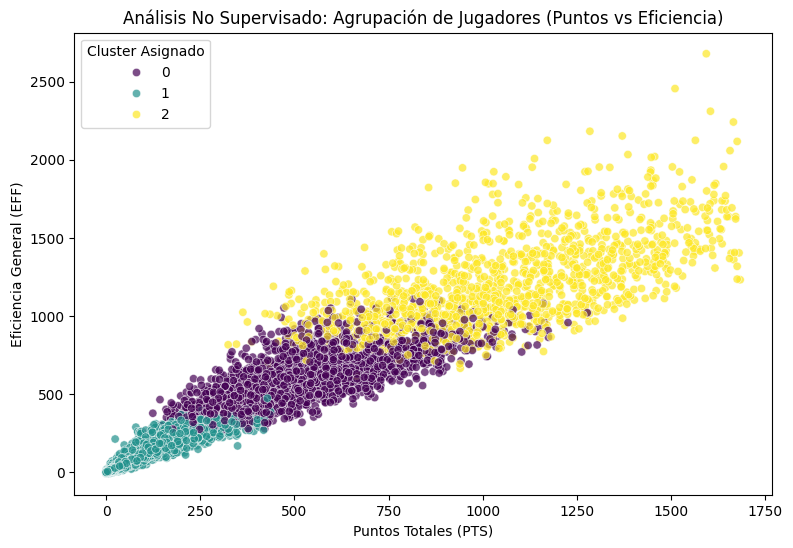


--- Promedio de Estadísticas por Grupo (Cluster) ---


,MIN,PTS,AST,REB,STL,BLK,TOV,EFF
Cluster_Jugador,,,,,,,,
0,1307.036315,517.924269,108.224535,221.660319,39.935784,24.550044,63.850753,591.760407
1,233.624581,84.874531,17.777865,39.932334,6.763070,4.467153,11.127836,97.127441
2,2166.980015,1045.524796,243.757217,421.349371,71.349371,48.045152,134.324944,1203.589933


In [3]:
# Celda 1: Importación de librerías para el cierre y clustering
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.cluster import KMeans
import joblib

# Celda 2: Carga de datos, particiones y todos los modelos entrenados
df_clean = pd.read_csv('nba_clean.csv')
X_train_scaled, X_test_scaled, y_train, y_test = joblib.load('data_partitions.pkl')

model_log = joblib.load('model_log_reg_base.pkl')
model_dt_base = joblib.load('model_dt_base.pkl')
model_dt_opt = joblib.load('model_dt_optimized.pkl')

# Celda 3: Comparativa Final de Rendimiento
models = {
    'Regresión Logística Base': model_log,
    'Árbol de Decisión Base': model_dt_base,
    'Árbol de Decisión Optimizado': model_dt_opt
}

summary_results = []
target_names = ['Regular Season', 'Playoffs']

for name, model in models.items():
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')
    summary_results.append({'Modelo': name, 'Accuracy': acc, 'F1-Score (Macro)': f1})

    print(f"\n=== Reporte Definitivo: {name} ===")
    print(classification_report(y_test, preds, target_names=target_names))

# Mostrar tabla comparativa consolidada
df_results = pd.DataFrame(summary_results)
print("\n--- TABLA COMPARATIVA DE MODELOS ---")
display(df_results)

# Celda 4: Integración No Supervisada (Patrones Ocultos con KMeans)
# Tomamos las características numéricas de todo el dataset
features_cols = ['MIN', 'PTS', 'AST', 'REB', 'STL', 'BLK', 'TOV', 'EFF']
scaler = joblib.load('scaler.pkl')
X_all_scaled = scaler.transform(df_clean[features_cols])

# Aplicamos KMeans para segmentar en 3 grupos de estilos de juego
kmeans = KMeans(n_clusters=3, random_state=42)
df_clean['Cluster_Jugador'] = kmeans.fit_predict(X_all_scaled)

# Celda 5: Visualización de los Perfiles de Jugadores Identificados
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='PTS', y='EFF',
    hue='Cluster_Jugador',
    data=df_clean,
    palette='viridis',
    alpha=0.7
)
plt.title('Análisis No Supervisado: Agrupación de Jugadores (Puntos vs Eficiencia)')
plt.xlabel('Puntos Totales (PTS)')
plt.ylabel('Eficiencia General (EFF)')
plt.legend(title='Cluster Asignado')
plt.show()

# Celda 6: Resumen Estadístico de los Clústers para conclusiones del informe
print("\n--- Promedio de Estadísticas por Grupo (Cluster) ---")
display(df_clean.groupby('Cluster_Jugador')[features_cols].mean())